In [21]:
import numpy as np
from astropy import units as u
from astropy.table import Table
from astropy.time import Time
from WDBinary import WDBinary
from WDBinary3 import WDBinary3

from scipy import integrate
from astropy.constants import G, c, M_sun

import matplotlib.pyplot as plt
from matplotlib import gridspec

In [22]:
# base params
mass_wd  = 0.634              
r_wd = 0.01166 * u.Rsun   
l_wd = 0.00120            
mass_star = 1.042            
r_star = 0.964 * u.Rsun     
l_star = 1.0               
ecc = 0.0               
a  = 0.4605 * u.au      
d = 808.0 * u.pc       
inc_deg  = 89.607 * u.deg  
omega_deg = 90.0 * u.deg      
cycle = 1
N=800000

# varying inclination

In [70]:
binaries_inc = []
inclinations = [89, 89.43, 89.44, 89.45, 89.47, 89.5, 89.6, 89.7, 89.8, 90] * u.deg 

for i in range(len(inclinations)):

    binary = WDBinary3(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc, a, d, omega=omega_deg, cycles=cycle,
        inc=inclinations[i],
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_inc.append(binary)


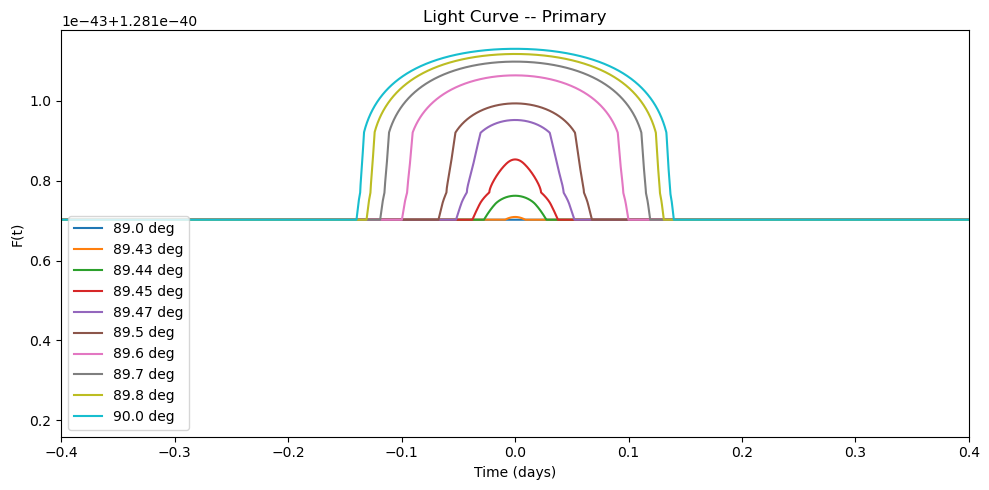

In [94]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(inclinations)):
    ax.plot((binaries_inc[i].t).to(u.day).value, binaries_inc[i].geo_flux, label=f'{inclinations[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-0.4, 0.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

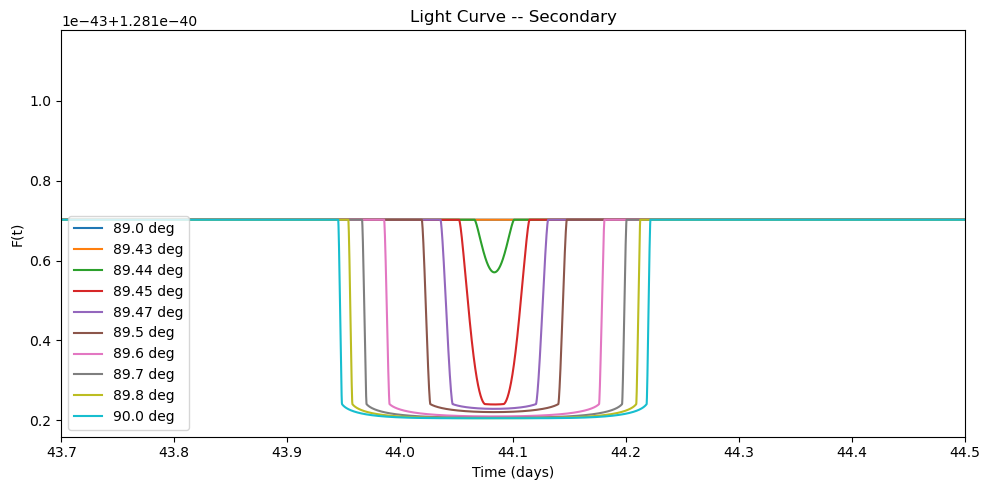

In [78]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(inclinations)):
    ax.plot((binaries_inc[i].t).to(u.day).value, binaries_inc[i].geo_flux, label=f'{inclinations[i]}')

ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(43.7, 44.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# varying eccentricity

In [ ]:
binaries_ecc = []
eccentricity = [0, 0.1, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for i in range(len(eccentricity)):

    binary = WDBinary3(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc=eccentricity[i], a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_ecc.append(binary)

/Users/wanglm/anaconda3/envs/pygyre_env/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


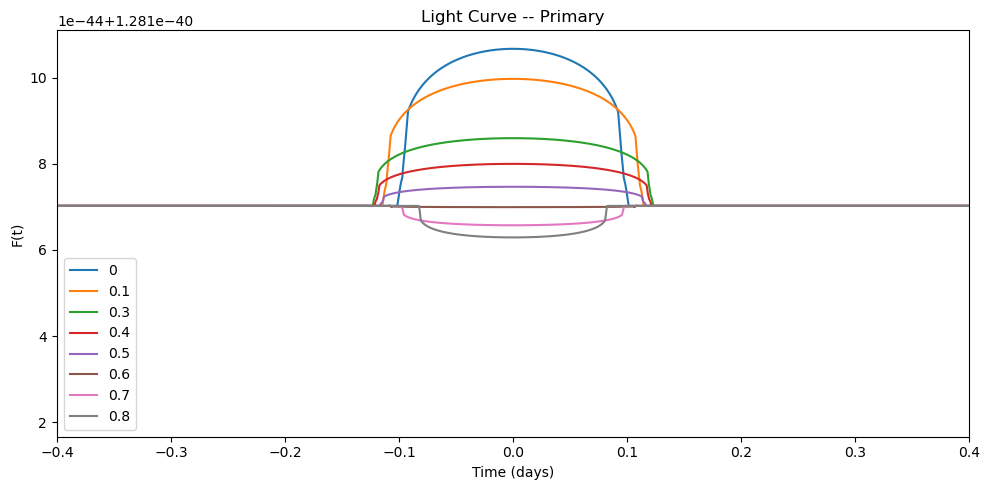

In [95]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(eccentricity)):
    ax.plot((binaries_ecc[i].t).to(u.day).value, binaries_ecc[i].geo_flux, label=f'{eccentricity[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-0.4, 0.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

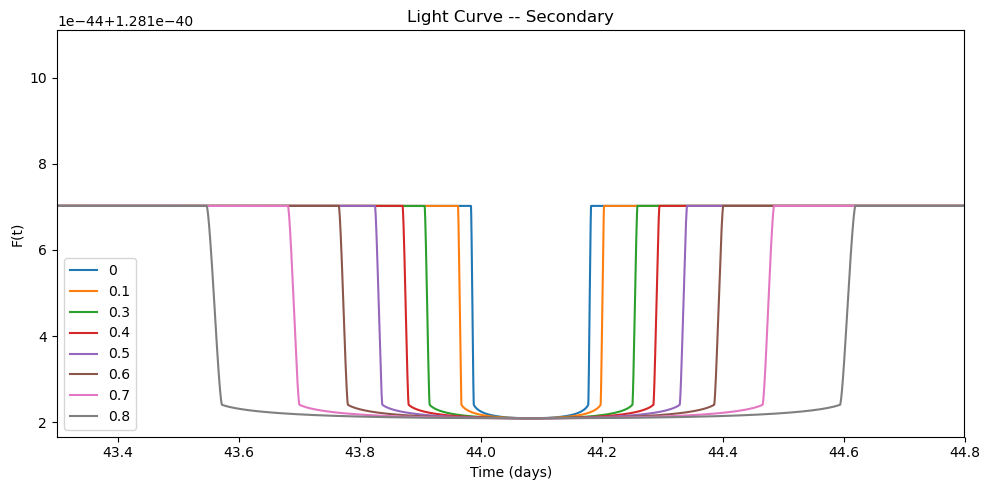

In [96]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(eccentricity)):
    ax.plot((binaries_ecc[i].t).to(u.day).value, binaries_ecc[i].geo_flux, label=f'{eccentricity[i]}')

ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(43.3, 44.8)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# varying semi-major axis

In [109]:
binaries_a = []
a_arr = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.65, 0.66, 0.7] * u.au

for i in range(len(a_arr)):

    binary = WDBinary3(
        mass_wd, r_wd, l_wd,
        mass_star, r_star, l_star,
        ecc, a=a_arr[i], d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_a.append(binary)

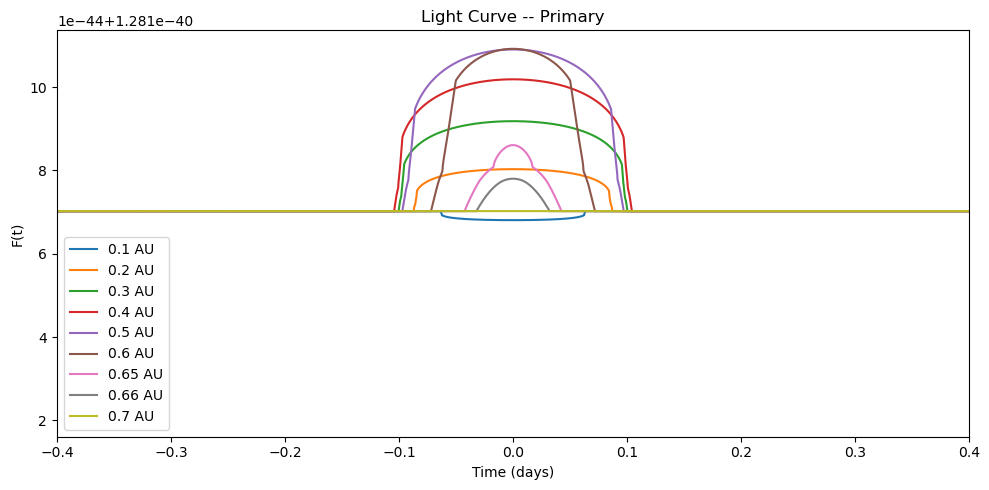

In [110]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(a_arr)):
    ax.plot((binaries_a[i].t).to(u.day).value, binaries_a[i].geo_flux, label=f'{a_arr[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-0.4, 0.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

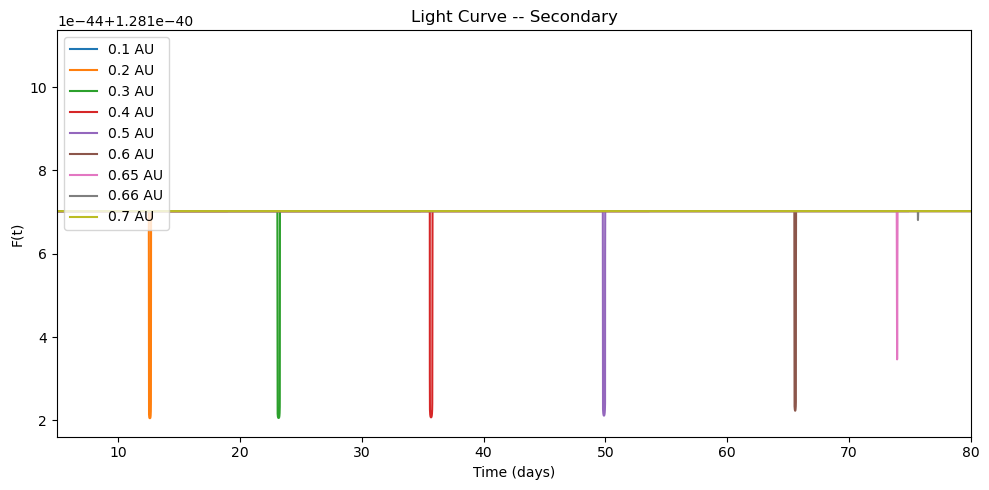

In [116]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(a_arr)):
    ax.plot((binaries_a[i].t).to(u.day).value, binaries_a[i].geo_flux, label=f'{a_arr[i]}')

ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(5, 80)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# varying R_{star}

In [127]:
binaries_rstars = []
rstars = [0.5, 0.68, 0.7, 0.85, 1.0, 2.0, 5.0] * u.Rsun 

for i in range(len(rstars)):

    binary = WDBinary3(
        mass_wd, r_wd, l_wd,
        mass_star, r_star=rstars[i], l_star=l_star,
        ecc=ecc, a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_rstars.append(binary)

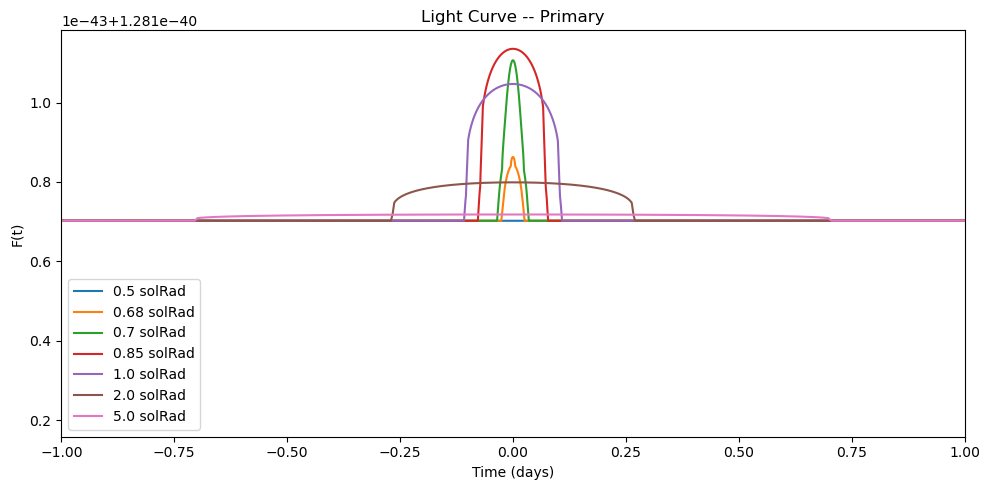

In [128]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(rstars)):
    ax.plot((binaries_rstars[i].t).to(u.day).value, binaries_rstars[i].geo_flux, label=f'{rstars[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-1, 1)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

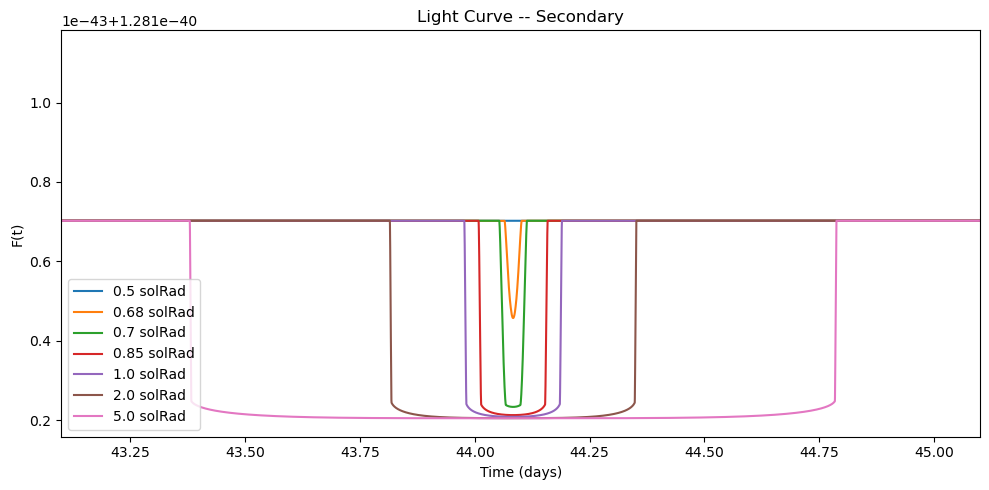

In [130]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(rstars)):
    ax.plot((binaries_rstars[i].t).to(u.day).value, binaries_rstars[i].geo_flux, label=f'{rstars[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Secondary")
ax.set_xlim(43.1, 45.1)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# varying R_{wd}

In [153]:
binaries_rwds = []
rwds = [0.000000001, 0.001, 0.01, 0.02, 0.03] * u.Rsun  

for i in range(len(rwds)):

    binary = WDBinary3(
        mass_wd, r_wd=rwds[i], l_wd=l_wd,
        mass_star=mass_star, r_star=r_star, l_star=l_star,
        ecc=ecc, a=a, d=d, omega=omega_deg, cycles=cycle,
        inc=inc_deg,
        limb_darkening_wd=[0.0, 0.1], limb_darkening_star=[0.44, 0.24],
        N=N
    )
    
    binaries_rwds.append(binary)

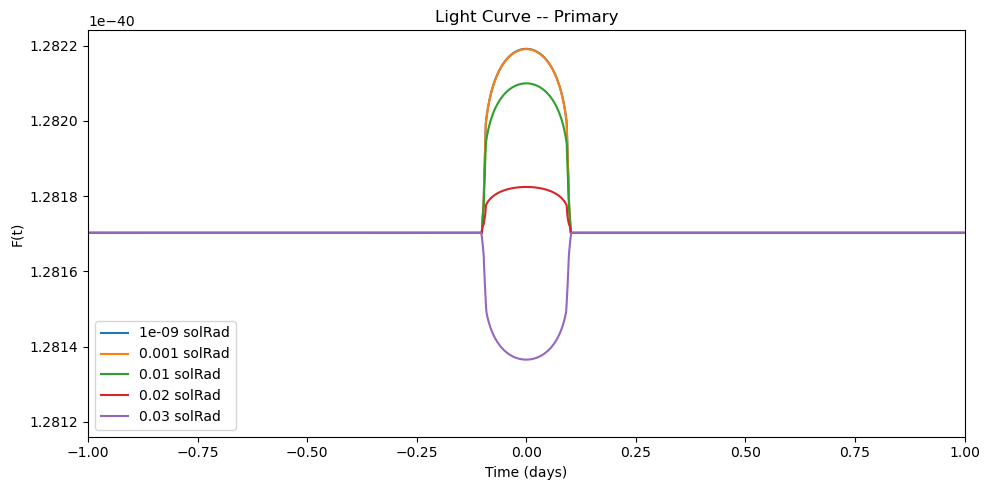

In [154]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(rwds)):
    ax.plot((binaries_rwds[i].t).to(u.day).value, binaries_rwds[i].geo_flux, label=f'{rwds[i]}')
ax.set_xlabel("Time (days)")
ax.set_ylabel("F(t)")
ax.set_title("Light Curve -- Primary")
ax.set_xlim(-1, 1)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()